In [1]:
import uxarray as ux
import xarray as xr
import numpy as np
import geocat.datafiles as gdf
import geocat.comp as gc
import geocat.datafiles as gdf
import matplotlib.pyplot as plt

In [18]:
#data_path = 'netcdf_files/e2p3b09.F2000climo.ne30pg3.ctl002.cam.h0.0005-01.zonal_mpsi_subset.nc'
#grid_path = 'netcdf_files/ne30pg3_scrip_170604.nc'

#uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')

data_path = 'hybrid_subset.nc'
grid_path = 'grid_subset.nc'
uxds = ux.open_dataset(grid_path, data_path)
uxds

<xarray.UxDataset> Size: 13kB
Dimensions:  (time: 1, lev: 32, n_face: 89)
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
Dimensions without coordinates: n_face
Data variables:
    V        (time, lev, n_face) float32 11kB ...
    PS       (time, n_face) float32 356B ...
    hyam     (lev) float64 256B ...
    hybm     (lev) float64 256B ...

In [6]:
# Subsetting
uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')


lon_bounds = (-110,-100)  # Full longitude
lat_bounds = (35, 45)

V_subset = uxds['V'].subset.bounding_box(
    lon_bounds,
    lat_bounds,
)
PS_subset = uxds['PS'].subset.bounding_box(
    lon_bounds,
    lat_bounds,
)

uxds = ux.UxDataset({
    'V': V_subset,
    'PS': PS_subset,
    'hyam': uxds['hyam'],
    'hybm': uxds['hybm']
}, uxgrid=V_subset.uxgrid)
uxds

/var/folders/dd/_xm_pbpd3flgbvbnt7qhd70snnbpj_/T/ipykernel_29686/3080202331.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')


<xarray.UxDataset> Size: 13kB
Dimensions:  (lev: 32, time: 1, n_face: 89)
Coordinates:
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 8B 0005-02-01 00:00:00
Dimensions without coordinates: n_face
Data variables:
    V        (time, lev, n_face) float32 11kB ...
    PS       (time, n_face) float32 356B ...
    hyam     (lev) float64 256B ...
    hybm     (lev) float64 256B ...

In [7]:
print(f"V_subset NaN count: {V_subset.isnull().sum().values}")
print(f"PS_subset NaN count: {PS_subset.isnull().sum().values}")

V_subset NaN count: 0
PS_subset NaN count: 0


In [8]:
da_ipress = gc.interpolation.interp_hybrid_to_pressure(
    uxds.V, 
    uxds.PS, 
    uxds.hyam, 
    uxds.hybm)
ux_ipress = ux.UxDataArray(da_ipress, uxgrid=uxds.uxgrid)
ux_ipress


/Users/jkent/Documents/GeoCAT/geocat-comp/geocat/comp/interpolation.py:721: UserWarning: Interpolation point out of data bounds encountered
  output = func_interpolate(


<xarray.UxDataArray 'V' (time: 1, plev: 21, n_face: 89)> Size: 15kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1, 21, 89))
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * plev     (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         m/s
    long_name:     Meridional wind
    cell_methods:  time: mean

In [9]:
lat_array = np.arange(lat_bounds[0]+1, lat_bounds[1], 1)
lat_array


array([36, 37, 38, 39, 40, 41, 42, 43, 44])

In [10]:
# zonal mean wind
ux_v_zonal = ux_ipress.zonal_mean(lat=lat_array)
ux_v_zonal['plev'] = ux_ipress.plev
ux_v_zonal


<xarray.DataArray 'V_zonal_mean' (time: 1, plev: 21, latitudes: 9)> Size: 2kB
array([[[            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [ 1.96818606e+00,  1.66549748e+00,  1.49353417e+00,
          1.30266858e+00,  9.84371276e-01,  3.48250815e-01,
         -4.52056499e-01, -1.17046434e+00, -1.99886067e+00],
        [ 5.53867751e+00,  4.96896343e+00,  4.29294887e+00,
          3.58884207e+00,  2.81673419e+00,  1.92549283e+00,
          1.09020952e+00,  2.74910827e-01, -6.33349780e-01],
        [ 7.98080972e+00,  7.51863351e+00,  6.84731288e+00,
          6.11436117e+00,  5.22885833e+00,  4.15120302e+00,
          2.89091455e+00,  1.67225008e+00,  4.40430462e-01],
        [ 1.04505683e+01,  9.83844279e+00,  9.06780139e+00,
          8.21959690e+00,  7.34433258e+00,  6.38142823e+00,
...
         -7.24385121e+00, -7.99376126e+00, -8.77927823e+00,
         -9.60782856e+00, -1.04741278e+01, -1.13885422e+01],
        [-6.71670878e+00, -7.74041475e+00, -8.82718097e+00,
         -9.97806872e+00, -1.11874885e+01, -1.24357688e+01,
         -1.37271880e+01, -1.50498380e+01, -1.64023204e+01],
        [-6.53375579e+00, -7.76091442e+00, -9.06928122e+00,
         -1.04575278e+01, -1.19159079e+01, -1.34195791e+01,
         -1.49683811e+01, -1.65471663e+01, -1.81432392e+01],
        [-5.10821756e+00, -6.64330560e+00, -8.27944853e+00,
         -1.00065280e+01, -1.18077372e+01, -1.36543304e+01,
         -1.55405898e+01, -1.74501013e+01, -1.93547186e+01],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan]]])
Coordinates:
  * plev       (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
  * latitudes  (latitudes) int64 72B 36 37 38 39 40 41 42 43 44
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False

In [11]:
ux_PS_zonal = uxds.PS.zonal_mean(lat=lat_array)
ux_PS_zonal

<xarray.DataArray 'PS_zonal_mean' (time: 1, latitudes: 9)> Size: 36B
array([[83334.195, 82125.87 , 81452.07 , 81478.664, 81912.04 , 82507.67 ,
        83321.78 , 84491.88 , 86408.78 ]], dtype=float32)
Coordinates:
  * latitudes  (latitudes) int64 72B 36 37 38 39 40 41 42 43 44
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False

In [12]:
# Constants
a = 6.371e6  # Earth radius (m)
g = 9.80665  # gravity (m/s^2)

lat = ux_v_zonal.latitudes
da_scaling_factor = 2 * np.pi * a * np.cos(lat) / g

In [13]:
np_dp_zonal = gc.meteorology.delta_pressure(ux_v_zonal.plev, ux_PS_zonal)

da_dp_zonal = xr.DataArray(
    np_dp_zonal,
    dims=["time", "latitudes", "plev"],
    coords={
        "plev": ux_v_zonal.plev,
        "latitudes": ux_v_zonal.latitudes
        },
    name="delta_pressure"
)
ux_dp_zonal = ux.UxDataArray(da_dp_zonal, uxgrid=uxds.uxgrid)

In [14]:
# Reverse plev, integrate, then reverse back
integrand = ux_v_zonal * ux_dp_zonal
ux_mpsi = (
    integrand.isel(plev=slice(None, None, -1))  # reverse plev: now top is first
    .cumsum(dim="plev")
)
ux_mpsi = ux_mpsi * da_scaling_factor

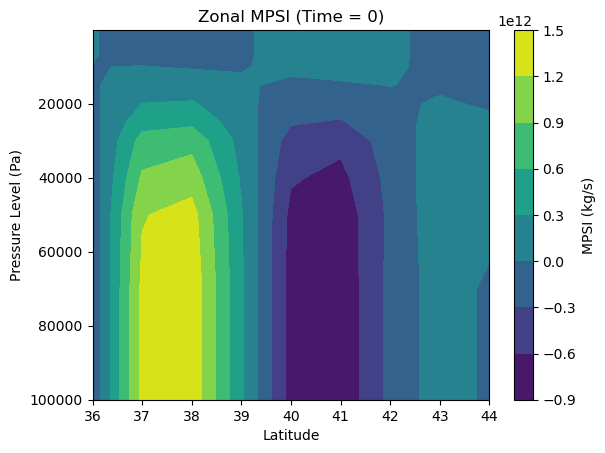

In [15]:
mpsi0 = ux_mpsi.isel(time=0)
plt.contourf(
    mpsi0['latitudes'],
    mpsi0['plev'],
    mpsi0
)
plt.xlabel("Latitude")
plt.ylabel("Pressure Level (Pa)")
plt.gca().invert_yaxis()
plt.colorbar(label="MPSI (kg/s)")
plt.title("Zonal MPSI (Time = 0)")
plt.show()

In [17]:
# Save the subsetted UxDataset
#uxds.to_netcdf('hybrid_subset.nc')

# Save the grid
V_subset.uxgrid.to_xarray().to_netcdf('grid_subset.nc')

# Save the interpolated pressure data
ux_ipress.to_netcdf('plev_subset.nc')